<a href="https://colab.research.google.com/github/Parul077/ML_Projects/blob/main/Analyzing_Air_Passenger_Data_using_Facebook_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Air Passenger Data using Facebook Prophet

In [1]:
!pip install prophet

In [2]:
import pandas as pd
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.plot import plot_plotly

In [3]:
url = ("https://raw.githubusercontent.com/rahulhegde99"
      "/Time-Series-Analysis-and-Forecasting-of-Air-Passengers"
        "/master/airpassengers.csv")
data = pd.read_csv(url)
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Facebook Prophet predicts data only when it is in a certain format. The dataframe with the data should have a column saved as ds for time series data and y for the data to be forecasted. Here, the time series is the column Month and the data to be forecasted is the column #Passengers. So, let's make a new DataFrame with new column names and the same data. Also, ds should be in a DateTime format

In [4]:
df = pd.DataFrame()
df['ds'] = pd.to_datetime(data['Month'])
df['y'] = data['#Passengers']
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


Initializing a Prophet Model

In [5]:
m = Prophet()
m.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


We want our model to predict the next 5 years, that is, till 1965. The frequency of our data is 1 month and thus for 5 years, it is 12 * 5 = 60 months. So, we need to add 60 to more rows of monthly data to a dataframe.

In [6]:
future = m.make_future_dataframe(periods=12 * 5, freq='M')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [7]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower',
          'yhat_upper', 'trend',
          'trend_lower', 'trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
199,1965-07-31,723.847944,694.410723,753.819029,656.874778,650.480007,663.282802
200,1965-08-31,677.972723,648.128838,706.618215,660.006426,653.421546,666.618159
201,1965-09-30,640.723591,610.097179,670.247469,663.037053,656.298787,669.795432
202,1965-10-31,610.965209,579.627985,641.288528,666.168701,659.318292,673.173146
203,1965-11-30,640.594097,612.079723,672.422081,669.199329,662.149336,676.431823


Table ***ds***, as we know, is the time series data.
***yhat*** is the prediction,
***yhat_lower***, and ***yhat_upper*** are the uncertainty levels (it basically means the prediction and actual values can vary within the bounds of the uncertainty levels).
Next up we have a ***trend*** that shows the long-term growth, shrink, or stagnancy of the data, ***trend_lower***, and ***trend_upper*** is the uncertainty levels.

Plotting the Forecast Data

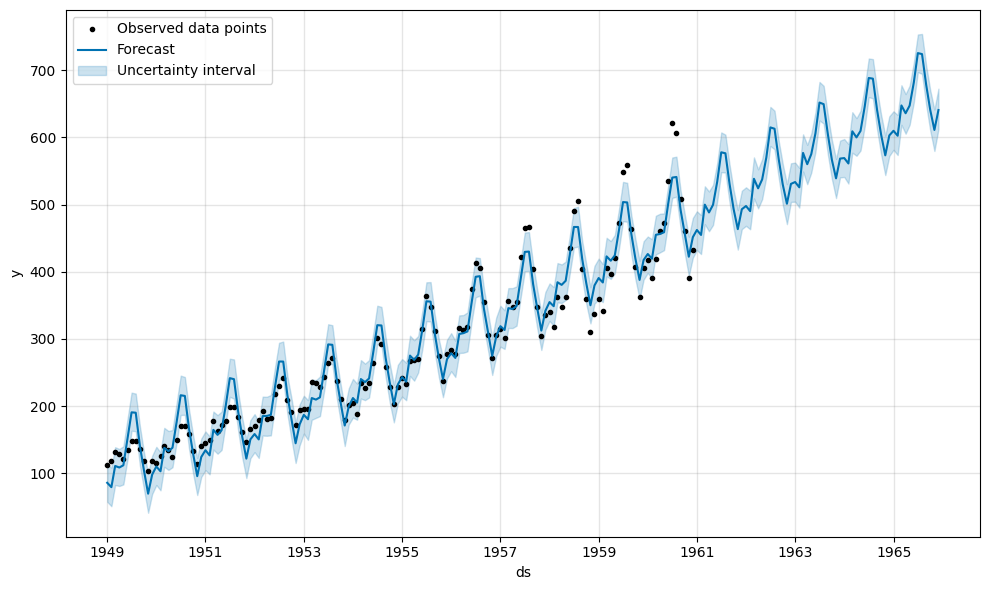

In [8]:
fig1 = m.plot(forecast, include_legend=True)

The image shows the basic prediction. The light blue is the **uncertainty level(yhat_upper and yhat_lower)**, the dark blue is the **prediction(yhat)** and the black dots are the **original data**. We can see that the predicted data is very close to the actual data. In the last five years, there is no "actual" data, but looking at the performance of our model in years where data is available it is safe to say that the predictions are close to accurate.

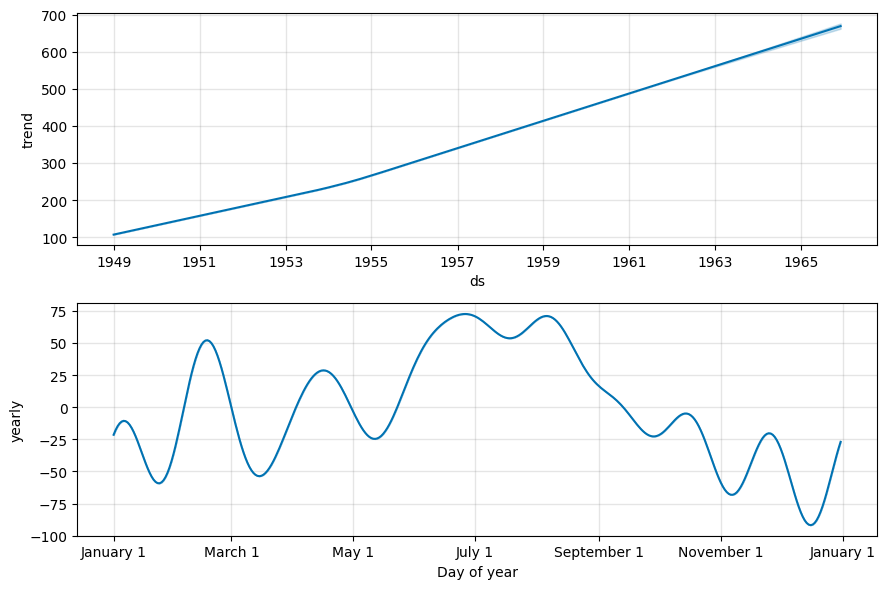

In [9]:
fig2 = m.plot_components(forecast)

The images show the trends and seasonality (in a year) of the time series data. We can see there is an **increasing trend, meaning the number of air passengers has increased over time**. If we look at the **seasonality graph, we can see that June and July is the time with the most passengers in a given year.**

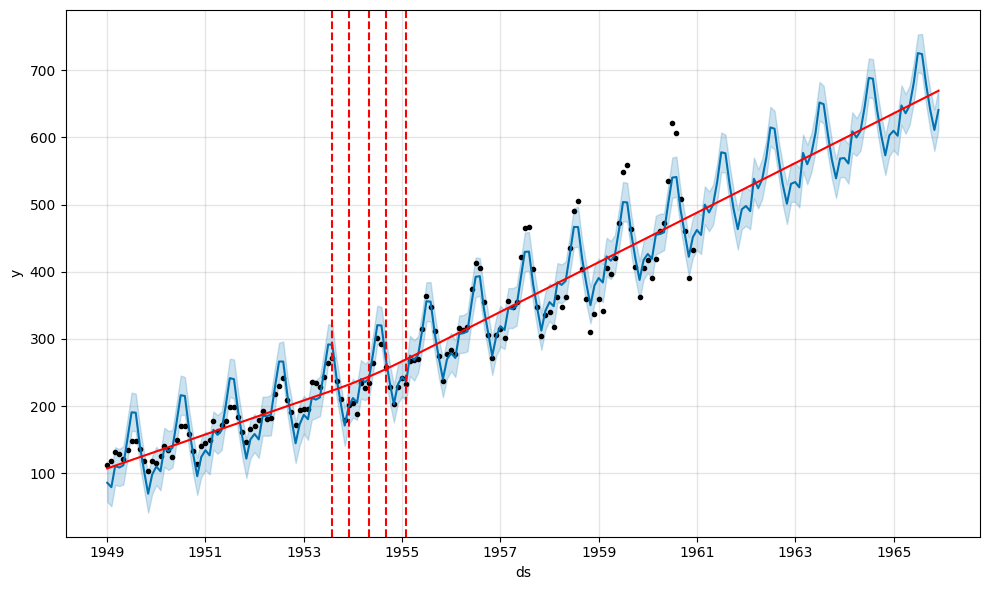

In [10]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

Add changepoints to indicate the time in rapid trend growths. The dotted **red lines show the time when there was a rapid change in the trend of the passengers**.